# Assignment 1: Explratory Data Analysis
*Author: Aidan Robin*

## Step 1: Data Cleaning

- I used functions like df_clean.describe() and df.isnull().sum() to find missing data. 
- I removed data where the days or highpoint was zero. A 0-day expedition is not possible and would ruin the integrity of the data. In addition, a highpoint of zero is not useful either.
- I chose not to normalize/scale the data because I felt it unecessecary and woiuld remove meaning.
- I decided to remove over half of the colums, only keeeping ones I need for upcoming parts.
- I removed outliers in the 'SMTDAYS' and 'TOTDAYS' because they are very skewed.
- Finally, I changed the type of YEAR to string, because year will be interpreted categorically in our data, not numerically.  

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns

%matplotlib inline

import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)

In [2]:
df = pd.read_csv("./himalayan_expeditions.csv")

df.head()

,Unnamed: 0,EXPID,PEAKID,YEAR,SEASON,HOST,ROUTE1,ROUTE2,ROUTE3,ROUTE4,NATION,LEADERS,SPONSOR,SUCCESS1,SUCCESS2,SUCCESS3,SUCCESS4,ASCENT1,ASCENT2,ASCENT3,ASCENT4,CLAIMED,DISPUTED,COUNTRIES,APPROACH,BCDATE,SMTDATE,SMTTIME,SMTDAYS,TOTDAYS,TERMDATE,TERMREASON,TERMNOTE,HIGHPOINT,TRAVERSE,SKI,PARAPENTE,CAMPS,ROPE,TOTMEMBERS,SMTMEMBERS,MDEATHS,TOTHIRED,SMTHIRED,HDEATHS,NOHIRED,O2USED,O2NONE,O2CLIMB,O2DESCENT,O2SLEEP,O2MEDICAL,O2TAKEN,O2UNKWN,OTHERSMTS,CAMPSITES,ROUTEMEMO,ACCIDENTS,ACHIEVMENT,AGENCY,COMRTE,STDRTE,PRIMRTE,PRIMMEM,PRIMREF,PRIMID,CHKSUM
0,8709,AMAD15101,AMAD,2015,Spring,Nepal,SW Ridge,NaN,NaN,NaN,Australia,Michael Groom,Australian Ama Dablam Expedition 2015,False,False,False,False,NaN,NaN,NaN,NaN,False,False,New Zealand,NaN,2015-04-23,2015-05-05,NaN,12,15,2015-05-08,"Bad conditions (deep snow, avalanching, fallin...",Abandoned at 6300m due to deep snow and old ta...,6300,False,False,False,2,800,10,0,0,2,0,0,False,True,False,False,False,False,True,False,False,NaN,"BC(23/04,4570m),C1(26/04,5700m),C2(27/04,5900m...",The route normally is mainly rock climbing up ...,NaN,NaN,Su-Swagatam Treks,True,False,False,False,False,NaN,2461953
1,8710,ANN115101,ANN1,2015,Spring,Nepal,N Face,NaN,NaN,NaN,Iran,Reza Shahlaee,Seven Summit Treks Annapurna I Expedition 2015,True,False,False,False,NaN,NaN,NaN,NaN,False,False,"China, Finland, Macedonia, Turkey","Pokhara, from Tatopani to BC by helicopter",2015-03-02,2015-03-24,1515.0,22,26,2015-03-28,Success (main peak),NaN,8091,False,False,False,4,0,7,7,1,6,6,1,False,True,False,True,False,False,False,False,False,NaN,"BC(02/03,4100m),C1(05/03,5100m),C2(09-10/03,56...",BC 02/03 4100m\r\nC1 05/03 5100m\r\nC2 09...,Irmak frostbite on all 10 toes; Dejanovic fros...,NaN,Dreamers Destination Treks,False,True,False,False,False,NaN,2462091
2,8711,CHOY15101,CHOY,2015,Spring,China,NW side,NaN,NaN,NaN,UK,Daniel Fuller,SummitClimb Cho Oyu Expedition 2015,False,False,False,False,NaN,NaN,NaN,NaN,False,False,"Australia, Austria, Germany, Romania, USA",NaN,2015-04-22,2015-04-27,NaN,5,38,2015-05-30,Other,Abandoned at 5200m due to earthquake,5200,False,False,False,0,0,7,0,0,3,0,0,False,False,True,False,False,False,False,True,False,NaN,"BC(22/04,4900m),xxx(27/04,5200m)",Despite the fact that on 25 April there had be...,NaN,NaN,Everest Parivar,True,True,False,False,False,NaN,2462800
3,8712,CHOY15102,CHOY,2015,Spring,China,NW side,NaN,NaN,NaN,India,Debasish Biswas,"Cho Oyu, Everest & Lhotse 2015",False,False,False,False,NaN,NaN,NaN,NaN,False,False,NaN,NaN,2015-04-20,2015-04-24,NaN,4,12,2015-05-02,Other,Abandoned at 5200m due to earthquake,5650,False,False,False,0,0,1,0,0,0,0,0,True,False,True,False,False,False,False,True,False,NaN,"BC(20/04,4850m),ABC(24/04,5650m),xxx(24/04,5650m)",BC 20/04 4850m\r\nABC 24/04 5650m\t\r\nHPt ...,NaN,NaN,Seven Summit Treks,True,True,False,False,False,NaN,2462797
4,8713,EVER15168,EVER,2015,Spring,Nepal,S Col-SE Ridge,NaN,NaN,NaN,USA,Garrett Madison,Madison Mountaineering Everest Expedition 2015,False,False,False,False,NaN,NaN,NaN,NaN,False,False,"Australia, Brazil, Guatemala, Germany, India, ...",NaN,2015-04-13,2015-04-25,NaN,12,14,2015-04-27,Other,Abandoned at 6500m due to earthquake,6500,False,False,False,2,0,17,0,1,20,0,0,False,False,True,False,False,False,False,True,False,Attempted Lhotse (LHOT-151-04),"BC(13/04),C1(22/04,6000m),C2(25/04,6500m),xxx(...","All members except Brier, Nissen and BC doctor...",NaN,NaN,Himalayan Guides,True,True,False,False,False,NaN,2459153


In [3]:
df.shape

(2730, 67)

In [4]:
cols_to_check = ['SMTDAYS', 'TOTDAYS', 'HIGHPOINT']
df = df[~(df[cols_to_check] == 0).any(axis=1)]
df.describe()

,Unnamed: 0,YEAR,ROUTE4,ASCENT3,ASCENT4,SMTTIME,SMTDAYS,TOTDAYS,HIGHPOINT,CAMPS,ROPE,TOTMEMBERS,SMTMEMBERS,MDEATHS,TOTHIRED,SMTHIRED,HDEATHS,CHKSUM
count,1485.000000,1485.000000,0.0,0.0,0.0,939.000000,1485.000000,1485.000000,1485.000000,1485.000000,1485.000000,1485.000000,1485.000000,1485.000000,1485.000000,1485.000000,1485.000000,1.485000e+03
mean,9954.416835,2018.345455,NaN,NaN,NaN,917.933972,19.162963,23.622896,7539.688215,2.630303,107.026936,5.544108,2.651178,0.028283,4.180471,2.371044,0.020875,2.454245e+06
std,712.268747,2.448359,NaN,NaN,NaN,331.463251,14.274517,14.881672,1048.459954,1.428917,579.645769,5.031596,3.467923,0.199075,6.010864,4.083244,0.214616,1.424982e+05
min,8709.000000,2015.000000,NaN,NaN,NaN,130.000000,1.000000,1.000000,4300.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.186000e+03
25%,9394.000000,2016.000000,NaN,NaN,NaN,651.500000,9.000000,13.000000,6700.000000,2.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.461167e+06
50%,9910.000000,2018.000000,NaN,NaN,NaN,900.000000,16.000000,21.000000,7650.000000,3.000000,0.000000,4.000000,2.000000,0.000000,2.000000,1.000000,0.000000,2.462706e+06
75%,10487.000000,2019.000000,NaN,NaN,NaN,1127.500000,29.000000,34.000000,8516.000000,4.000000,0.000000,7.000000,4.000000,0.000000,5.000000,3.000000,0.000000,2.463682e+06
max,11576.000000,2024.000000,NaN,NaN,NaN,2359.000000,278.000000,280.000000,8849.000000,17.000000,8500.000000,47.000000,32.000000,3.000000,54.000000,43.000000,6.000000,2.466843e+06


In [5]:
df.shape

(1485, 67)

In [6]:
df.isnull().sum()

Unnamed: 0       0
EXPID            0
PEAKID           0
YEAR             0
SEASON           0
HOST             1
ROUTE1           2
ROUTE2        1448
ROUTE3        1484
ROUTE4        1485
NATION           0
LEADERS          0
SPONSOR          8
SUCCESS1         0
SUCCESS2         0
SUCCESS3         0
SUCCESS4         0
ASCENT1       1398
ASCENT2       1482
ASCENT3       1485
ASCENT4       1485
CLAIMED          0
DISPUTED         0
COUNTRIES      706
APPROACH       213
BCDATE           0
SMTDATE          0
SMTTIME        546
SMTDAYS          0
TOTDAYS          0
TERMDATE         0
TERMREASON       2
TERMNOTE      1007
HIGHPOINT        0
TRAVERSE         0
SKI              0
PARAPENTE        0
CAMPS            0
ROPE             0
TOTMEMBERS       0
SMTMEMBERS       0
MDEATHS          0
TOTHIRED         0
SMTHIRED         0
HDEATHS          0
NOHIRED          0
O2USED           0
O2NONE           0
O2CLIMB          0
O2DESCENT        0
O2SLEEP          0
O2MEDICAL        0
O2TAKEN     

In [7]:
#Filtering columns

regex_df = df.filter(regex='PEAKID|SUCCESS.|.DAYS$')
cols_df = df.filter(items = ['PEAKID','YEAR','SEASON','HIGHPOINT','CAMPS','TERMREASON'])
reduced_df = regex_df.merge(cols_df)
reduced_df.head(20)

,PEAKID,SUCCESS1,SUCCESS2,SUCCESS3,SUCCESS4,SMTDAYS,TOTDAYS,YEAR,SEASON,HIGHPOINT,CAMPS,TERMREASON
0,AMAD,False,False,False,False,12,15,2015,Spring,6300,2,"Bad conditions (deep snow, avalanching, fallin..."
1,AMAD,False,False,False,False,12,15,2015,Spring,6000,0,Other
2,AMAD,False,False,False,False,12,15,2015,Autumn,6814,2,Success (main peak)
3,AMAD,False,False,False,False,12,15,2015,Autumn,5800,1,"Lack (or loss) of supplies, support or equipment"
4,AMAD,False,False,False,False,12,15,2015,Autumn,6814,2,Success (main peak)
5,AMAD,False,False,False,False,12,15,2015,Autumn,6814,2,Success (main peak)
6,AMAD,False,False,False,False,12,15,2015,Autumn,5300,1,Other
7,AMAD,False,False,False,False,12,15,2015,Autumn,6814,2,Success (main peak)
8,AMAD,False,False,False,False,12,15,2015,Autumn,6814,2,Success (main peak)
9,AMAD,False,False,False,False,12,15,2015,Autumn,6814,2,Success (main peak)


In [8]:
# Removing outliers
cols = ['SMTDAYS', 'TOTDAYS', 'CAMPS']

# Calculate bounds for both
Q1 = reduced_df[cols].quantile(0.25)
Q3 = reduced_df[cols].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# Filter: Keep rows where BOTH columns are within their respective bounds
df_clean = reduced_df[~((reduced_df[cols] < lower) | (reduced_df[cols] > upper)).any(axis=1)]

In [9]:
df_clean.dtypes

PEAKID          str
SUCCESS1       bool
SUCCESS2       bool
SUCCESS3       bool
SUCCESS4       bool
SMTDAYS       int64
TOTDAYS       int64
YEAR          int64
SEASON          str
HIGHPOINT     int64
CAMPS         int64
TERMREASON      str
dtype: object

In [10]:
df_clean= df_clean.astype({'YEAR': str})
df_clean.dtypes

PEAKID          str
SUCCESS1       bool
SUCCESS2       bool
SUCCESS3       bool
SUCCESS4       bool
SMTDAYS       int64
TOTDAYS       int64
YEAR            str
SEASON          str
HIGHPOINT     int64
CAMPS         int64
TERMREASON      str
dtype: object

## Step 2: Describing the dataset
- I seperated the columns between categorical and numerical data. 
- For the numerical values, I made density and histogram plots for each variable.
- For the categorical values, I made bar charts for each variable.
- Even after removing outliers, the numerical data is still skewed or bimodal.
- I did not graph the boolean types, because I did not think it would be interesting.


--- Statistics for SMTDAYS ---
              mean  median  mode        std    variance  min   max
SMTDAYS  23.957949    26.0    30  12.618111  159.216731  1.0  53.0


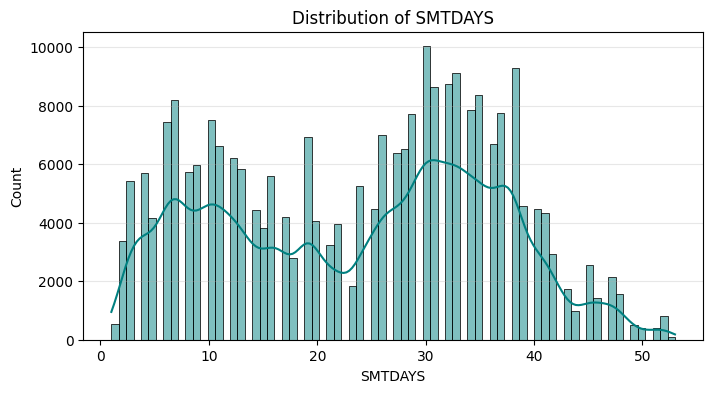


--- Statistics for TOTDAYS ---
              mean  median  mode        std   variance  min   max
TOTDAYS  28.548381    31.0    33  13.029161  169.75903  1.0  67.0


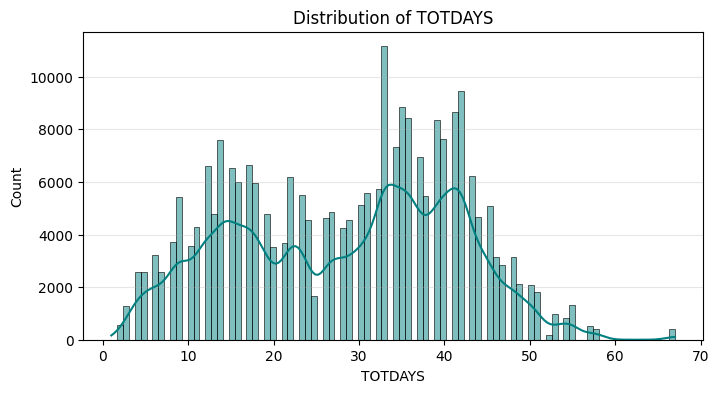


--- Statistics for HIGHPOINT ---
                  mean  median  mode         std       variance     min  \
HIGHPOINT  8067.331941  8580.0  8849  982.177041  964671.739529  4300.0   

              max  
HIGHPOINT  8849.0  


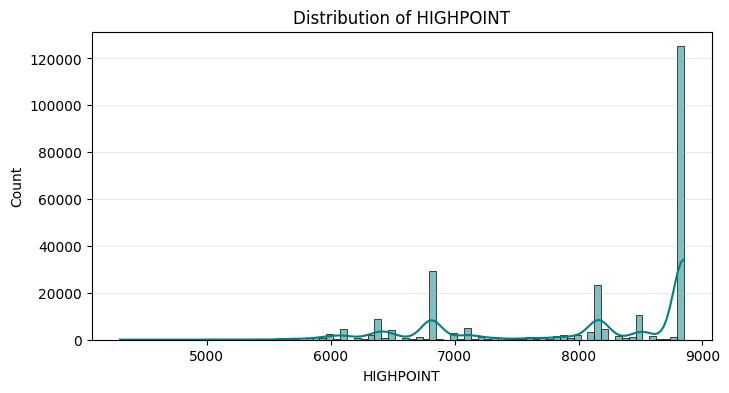


--- Statistics for CAMPS ---
           mean  median  mode       std  variance  min  max
CAMPS  3.026143     3.0     4  1.220576  1.489807  0.0  7.0


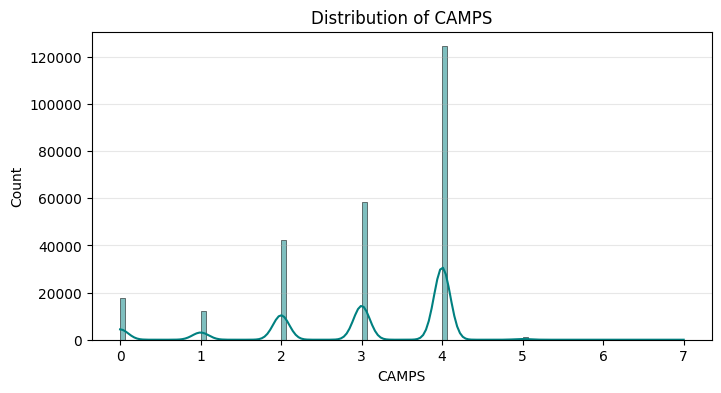

In [11]:
num_cols = df_clean.select_dtypes(include=['number'])
cat_cols = df_clean.select_dtypes(include=['str'])

# descriptive stats for numerical vals
for col in num_cols:
    print(f"\n--- Statistics for {col} ---")
    stats = df_clean[col].describe().to_frame().T
    stats['median'] = df_clean[col].median()
    stats['mode'] = df_clean[col].mode()[0]
    stats['variance'] = df_clean[col].var()
    print(stats[['mean', 'median', 'mode', 'std', 'variance', 'min', 'max']])
    
    plt.figure(figsize=(8, 4))
    sns.histplot(df_clean[col], kde=True, color='teal')
    plt.title(f'Distribution of {col}')
    plt.grid(axis='y', alpha=0.3)
    plt.show()


--- Frequency Count for PEAKID ---
PEAKID
EVER    165649
AMAD     34225
MANA     28561
LHOT     12100
CHOY      5041
HIML      3481
MAKA      2809
DHA1      2809
ANN1       961
KANG       400
BARU       361
PUTH       324
PUMO       144
ANN4        81
CHAM        81
NUPT        81
TKPO        49
MUKT        25
RATC        25
KCHS        16
CHUG        16
LUNR        16
TUKU        16
LDNG        16
CHOL        16
HONK        16
CHOB         9
LDAK         9
APIM         9
TILI         9
BURK         9
PAND         9
OMIT         9
RIPI         9
PANB         9
GYAJ         9
TENR         9
CBAM         4
TSAR         4
TAWO         4
TKRE         4
ANN3         4
DANS         4
PAWR         4
KIMS         4
TOBS         4
MALA         4
PURK         4
BHRI         4
BHRS         4
CHEK         4
DOLM         4
GANW         4
KORL         4
KYAZ         4
LARK         4
NAG1         4
NUPW         4
GANG         4
HIMJ         4
KGRI         4
LANY         4
NILN         4
SITA        

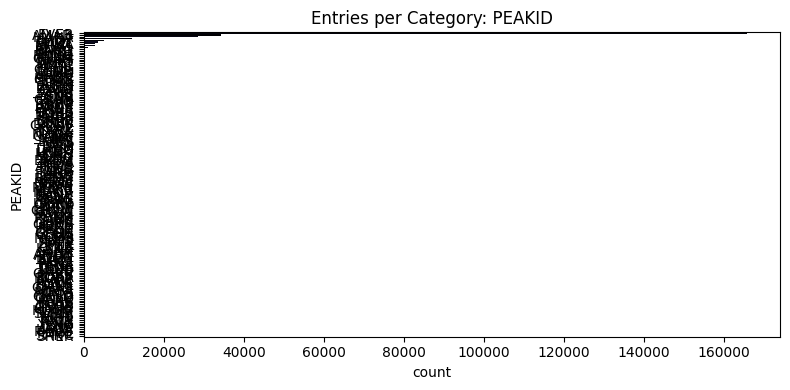


--- Frequency Count for YEAR ---
YEAR
2017    50139
2019    46297
2018    44978
2016    40479
2015    25100
2021    21218
2022    14114
2023     8421
2024     5712
2020     1207
Name: count, dtype: int64


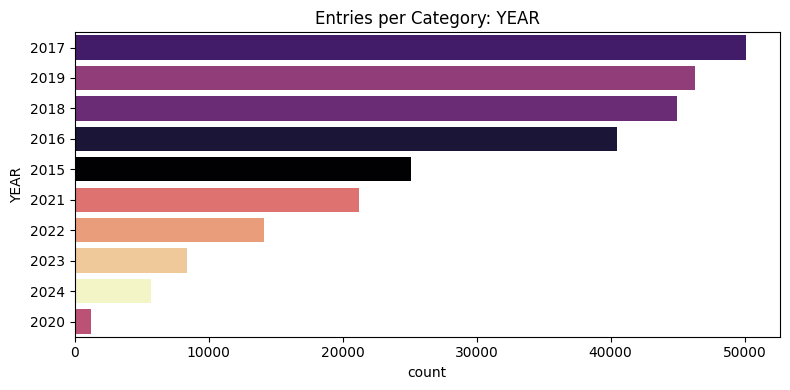


--- Frequency Count for SEASON ---
SEASON
Spring    186672
Autumn     67266
Winter      3662
Summer        65
Name: count, dtype: int64


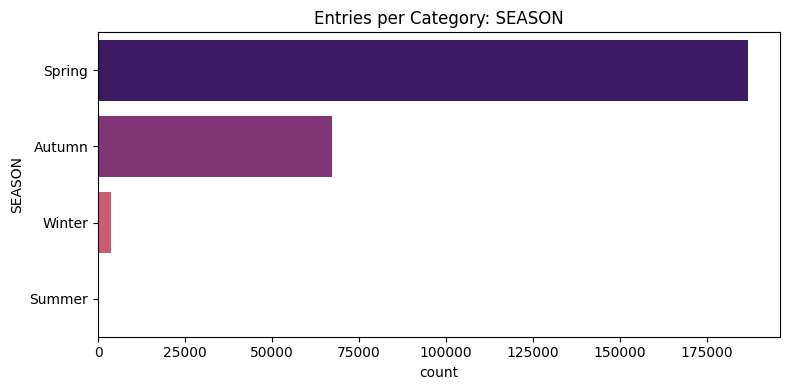


--- Frequency Count for TERMREASON ---
TERMREASON
Success (main peak)                                                             191841
Other                                                                            22056
Bad weather (storms, high winds)                                                 14601
Bad conditions (deep snow, avalanching, falling ice, or rock)                     8314
Illness, AMS, exhaustion, or frostbite                                            7885
Success (subpeak, foresummit)                                                     4488
Lack (or loss) of supplies, support or equipment                                  4388
Accident (death or serious injury)                                                1872
Route technically too difficult, lack of experience, strength, or motivation      1271
Lack of time                                                                       712
Success (claimed)                                                              

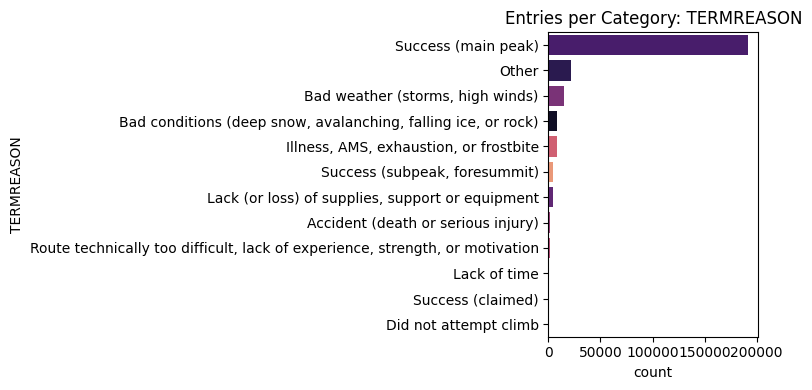

In [12]:
# descriptive statistics for categorical values
for col in cat_cols:
    if col == 'EXPID':
        continue
    
    print(f"\n--- Frequency Count for {col} ---")
    print(reduced_df[col].value_counts())
    
    plt.figure(figsize=(8, 4))
    sns.countplot(y=reduced_df[col], hue=reduced_df[col],legend=False, palette='magma', order=reduced_df[col].value_counts().index)
    plt.title(f'Entries per Category: {col}')
    plt.tight_layout()
    plt.show()


## Step 3: Identifying Patterns and Relationships

**What does it mean to "fail" in our dataset?**
- For us, a failed expedition means that all of the SUCCESS booleans are false or TERMREASON is success.

**What are conditions that are "outside of the expeditions contol"?**
- We will use TERMREASON to define conditions that are outside of our control. Bad weather and bad conditions are considered outside of out control. In addition, illnesses and injuries are also "outside of our control" because although climbers can take preventative measures, you can never fully prepare for an accident.

**Results**
- Upon analyzing the bar graph, we find that expidentions fail due to conditions outside of their control more often than not. I expected this, but the proportion was a lot closer than I thought. I believed that outside factors would be the overwhelming reason why expeditions fail, but it actually accounted for only 54.9% of failures.

In [13]:
outside_control = [
    'Bad weather (storms, high winds)', 
    'Bad conditions (deep snow, avalanching, falling ice, or rock)', 
    'Illness, AMS, exhaustion, or frostbite', 
    'Accident (death or serious injury)'
]

df_clean['is_outside_control'] = df_clean['TERMREASON'].isin(outside_control)

successful_term = [
    'Success (main peak)',
    'Success (subpeak, foresummit)'
]

df_clean['is_fail'] = (df_clean['SUCCESS1'] == False) & (df_clean['SUCCESS2'] == False) & (df_clean['SUCCESS3'] == False) & (df_clean['SUCCESS4'] == False) & ~df_clean['TERMREASON'].isin(successful_term)
df_clean['is_success'] = ~df_clean['is_fail']

failed_df = df_clean[df_clean['is_fail'] == True]

failed_df.head()

,PEAKID,SUCCESS1,SUCCESS2,SUCCESS3,SUCCESS4,SMTDAYS,TOTDAYS,YEAR,SEASON,HIGHPOINT,CAMPS,TERMREASON,is_outside_control,is_fail,is_success
0,AMAD,False,False,False,False,12,15,2015,Spring,6300,2,"Bad conditions (deep snow, avalanching, fallin...",True,True,False
1,AMAD,False,False,False,False,12,15,2015,Spring,6000,0,Other,False,True,False
3,AMAD,False,False,False,False,12,15,2015,Autumn,5800,1,"Lack (or loss) of supplies, support or equipment",False,True,False
6,AMAD,False,False,False,False,12,15,2015,Autumn,5300,1,Other,False,True,False
15,AMAD,False,False,False,False,12,15,2016,Spring,6400,2,"Bad weather (storms, high winds)",True,True,False


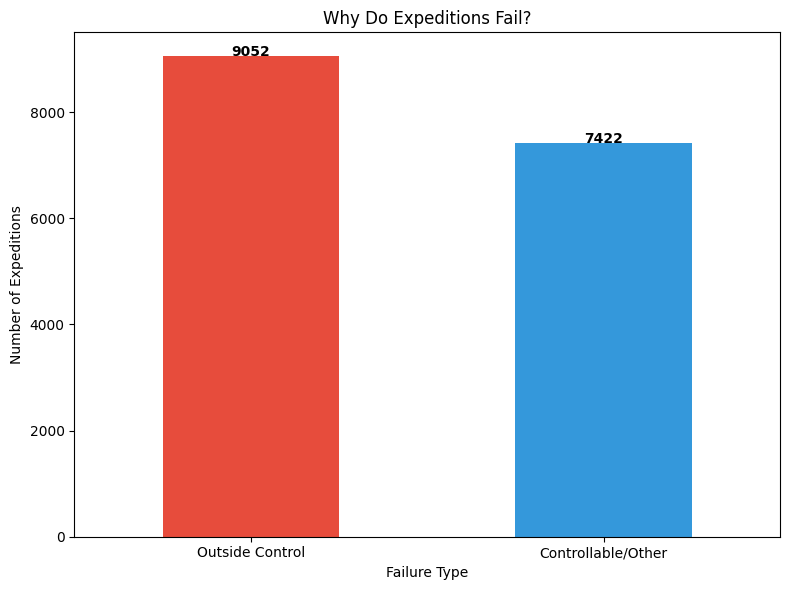

In [14]:
why_fail = failed_df['is_outside_control'].value_counts().rename({
    True: 'Outside Control', 
    False: 'Controllable/Other'
})

plt.figure(figsize=(8, 6))
why_fail.plot(kind='bar', color=['#e74c3c', '#3498db'])

plt.title('Why Do Expeditions Fail?')
plt.ylabel('Number of Expeditions')
plt.xlabel('Failure Type')
plt.xticks(rotation=0)

for i, v in enumerate(why_fail):
    plt.text(i, v + 0.5, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## Step 4: Insights of Himalayan Mountaineering Expeditions
**Everest annual success vs failure**
- To find which expeditions successfully climb Mount Everest each year, I needed to use the PEAKID, YEAR, and is_fail (created in previous part) columns.
- I wanted to show the rate of success vs failure, so I had to normalize the data before plotting it. 
- The data shows that people who climb Mount Everest usually succeed, with the success rate being over 75% in all years.
**Number of camps vs Outcome**
- I also decided to see if the number of camps correlated with success climbing Everest.
- Using a boxplot, the data revealted that those who visited more camps tended to be more successful.
**Altitude of Failure**
- The most interesting trend I found was create a density graph that graphed the HIGHPOINT that was reached for each expedition that failed.
- The data revealed an incredible finding: there is a huge chokepoint at around 6500 meters. This altitude is the failure point for a significant number of expeditions.


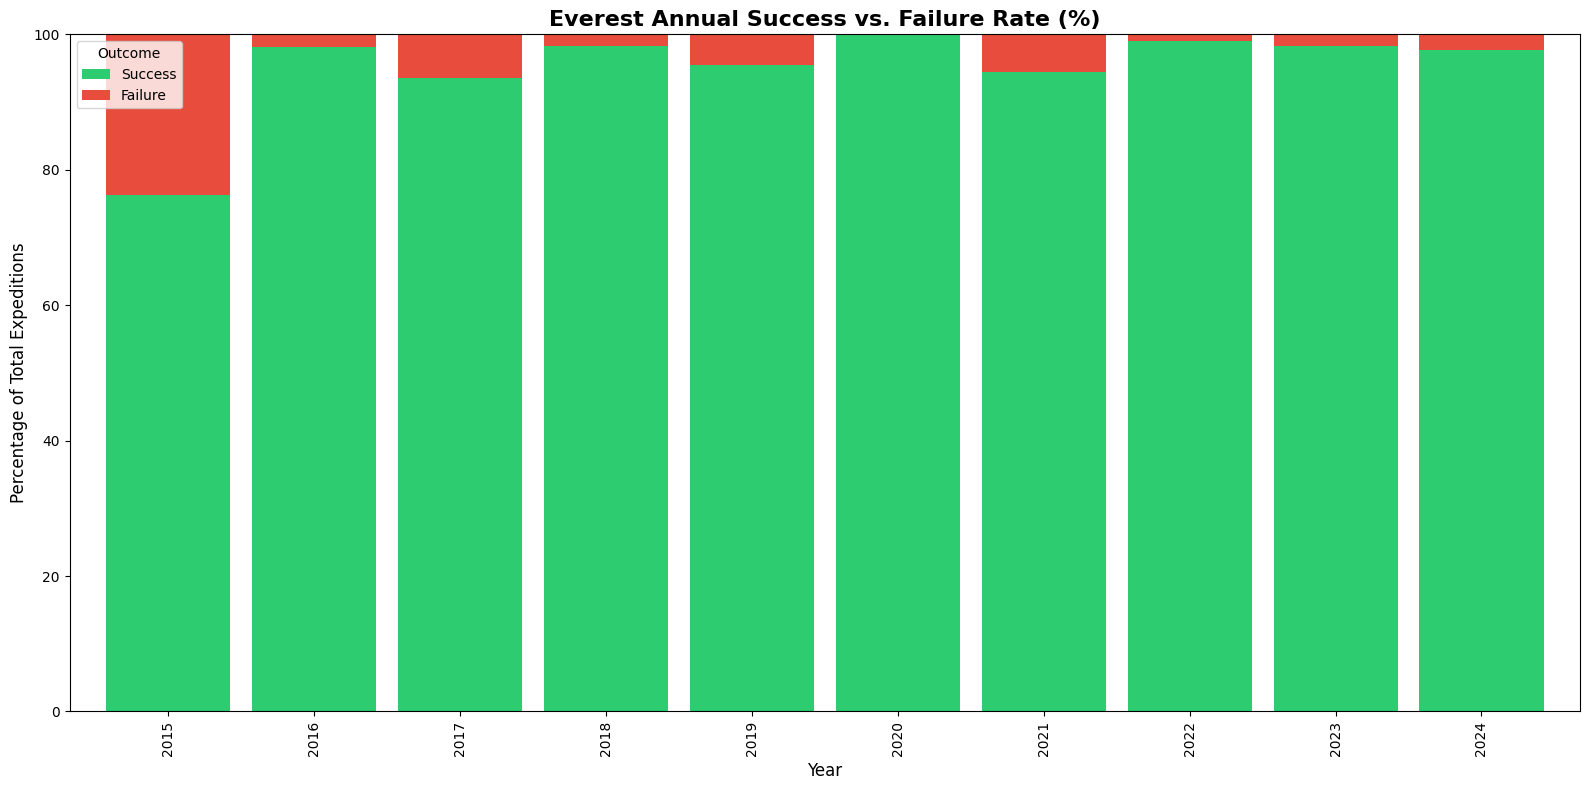

In [15]:
everest_df = df_clean[df_clean['PEAKID'] == 'EVER']
everest_df['YEAR'] = pd.to_numeric(everest_df['YEAR'])
everest_df['Status'] = everest_df['is_fail'].map({False: 'Success', True: 'Failure'})

yearly_stats = pd.crosstab(everest_df['YEAR'], everest_df['Status'])

yearly_pct = yearly_stats.div(yearly_stats.sum(axis=1), axis=0) * 100
yearly_pct = yearly_pct[['Success', 'Failure']]
everest_df.head()

plt.figure(figsize=(16, 8))
yearly_pct.plot(kind='bar', 
                stacked=True, 
                color=['#2ecc71','#e74c3c'], 
                width=0.85,
                ax=plt.gca())

plt.title('Everest Annual Success vs. Failure Rate (%)', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Percentage of Total Expeditions', fontsize=12)
plt.ylim(0, 100) # Always 0-100 for percentage charts
plt.legend(title='Outcome', loc='upper left')

plt.tight_layout()
plt.show()


C:\Users\APR86\AppData\Local\Temp\ipykernel_17492\2961915477.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='is_success', y='CAMPS', data=everest_df, palette='Set2')


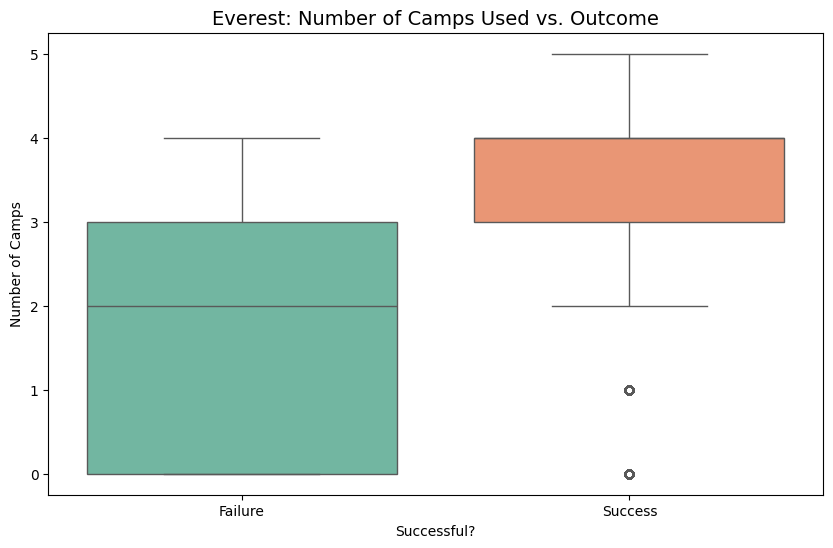

In [16]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='is_success', y='CAMPS', data=everest_df, palette='Set2')
plt.title('Everest: Number of Camps Used vs. Outcome', fontsize=14)
plt.xticks([0, 1], ['Failure', 'Success'])
plt.ylabel('Number of Camps')
plt.xlabel('Successful?')
plt.show()

C:\Users\APR86\AppData\Local\Temp\ipykernel_17492\2565168344.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


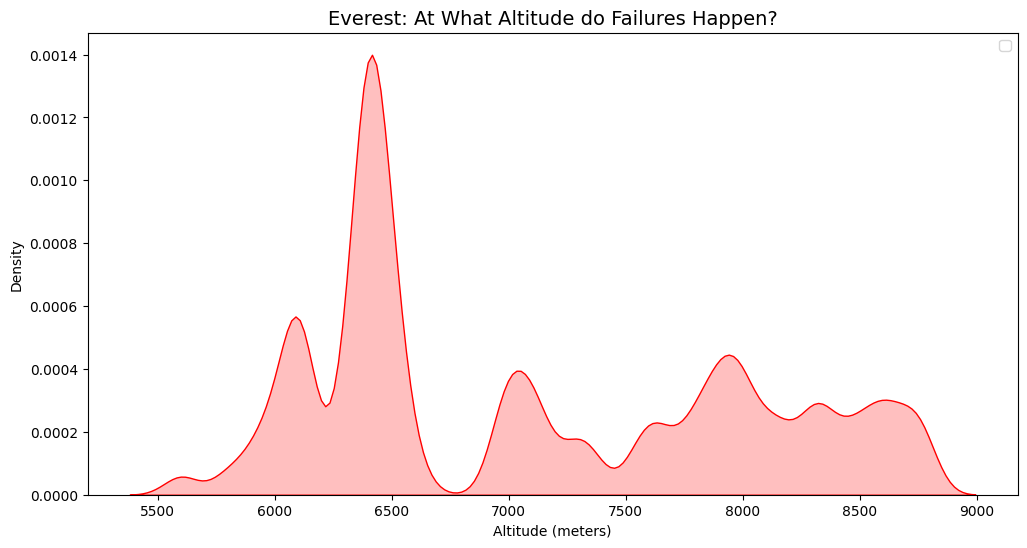

In [17]:
failed_everest = everest_df[everest_df['is_fail'] == True]

plt.figure(figsize=(12, 6))
sns.kdeplot(data=failed_everest, x='HIGHPOINT', fill=True, color='red', bw_adjust=0.5)

plt.title('Everest: At What Altitude do Failures Happen?', fontsize=14)
plt.xlabel('Altitude (meters)')
plt.legend()
plt.show()

## Step 5: Visualization
- To graph Season, Highest Point, Success, and Days, we need to use a scatterplot with four features: x, y, color, and size.
- I decided to assign x and y to Days and Highest Point, respectively. I felt this made sesne because they are both numerical values. In addition, Highest Point is associated with height, so it makes sense to associate it with the y-axis.
- I decided to map colors to Seasons and size to Success. I initially tried the other way around, but with so many points, I found it extremely tough to differenciate between the four sizes.
- Looking at the visualiztion, it seems that there is a relationshp between Days and Success. If the expedition was really long (over 60 days), it was unlikely to end in success.

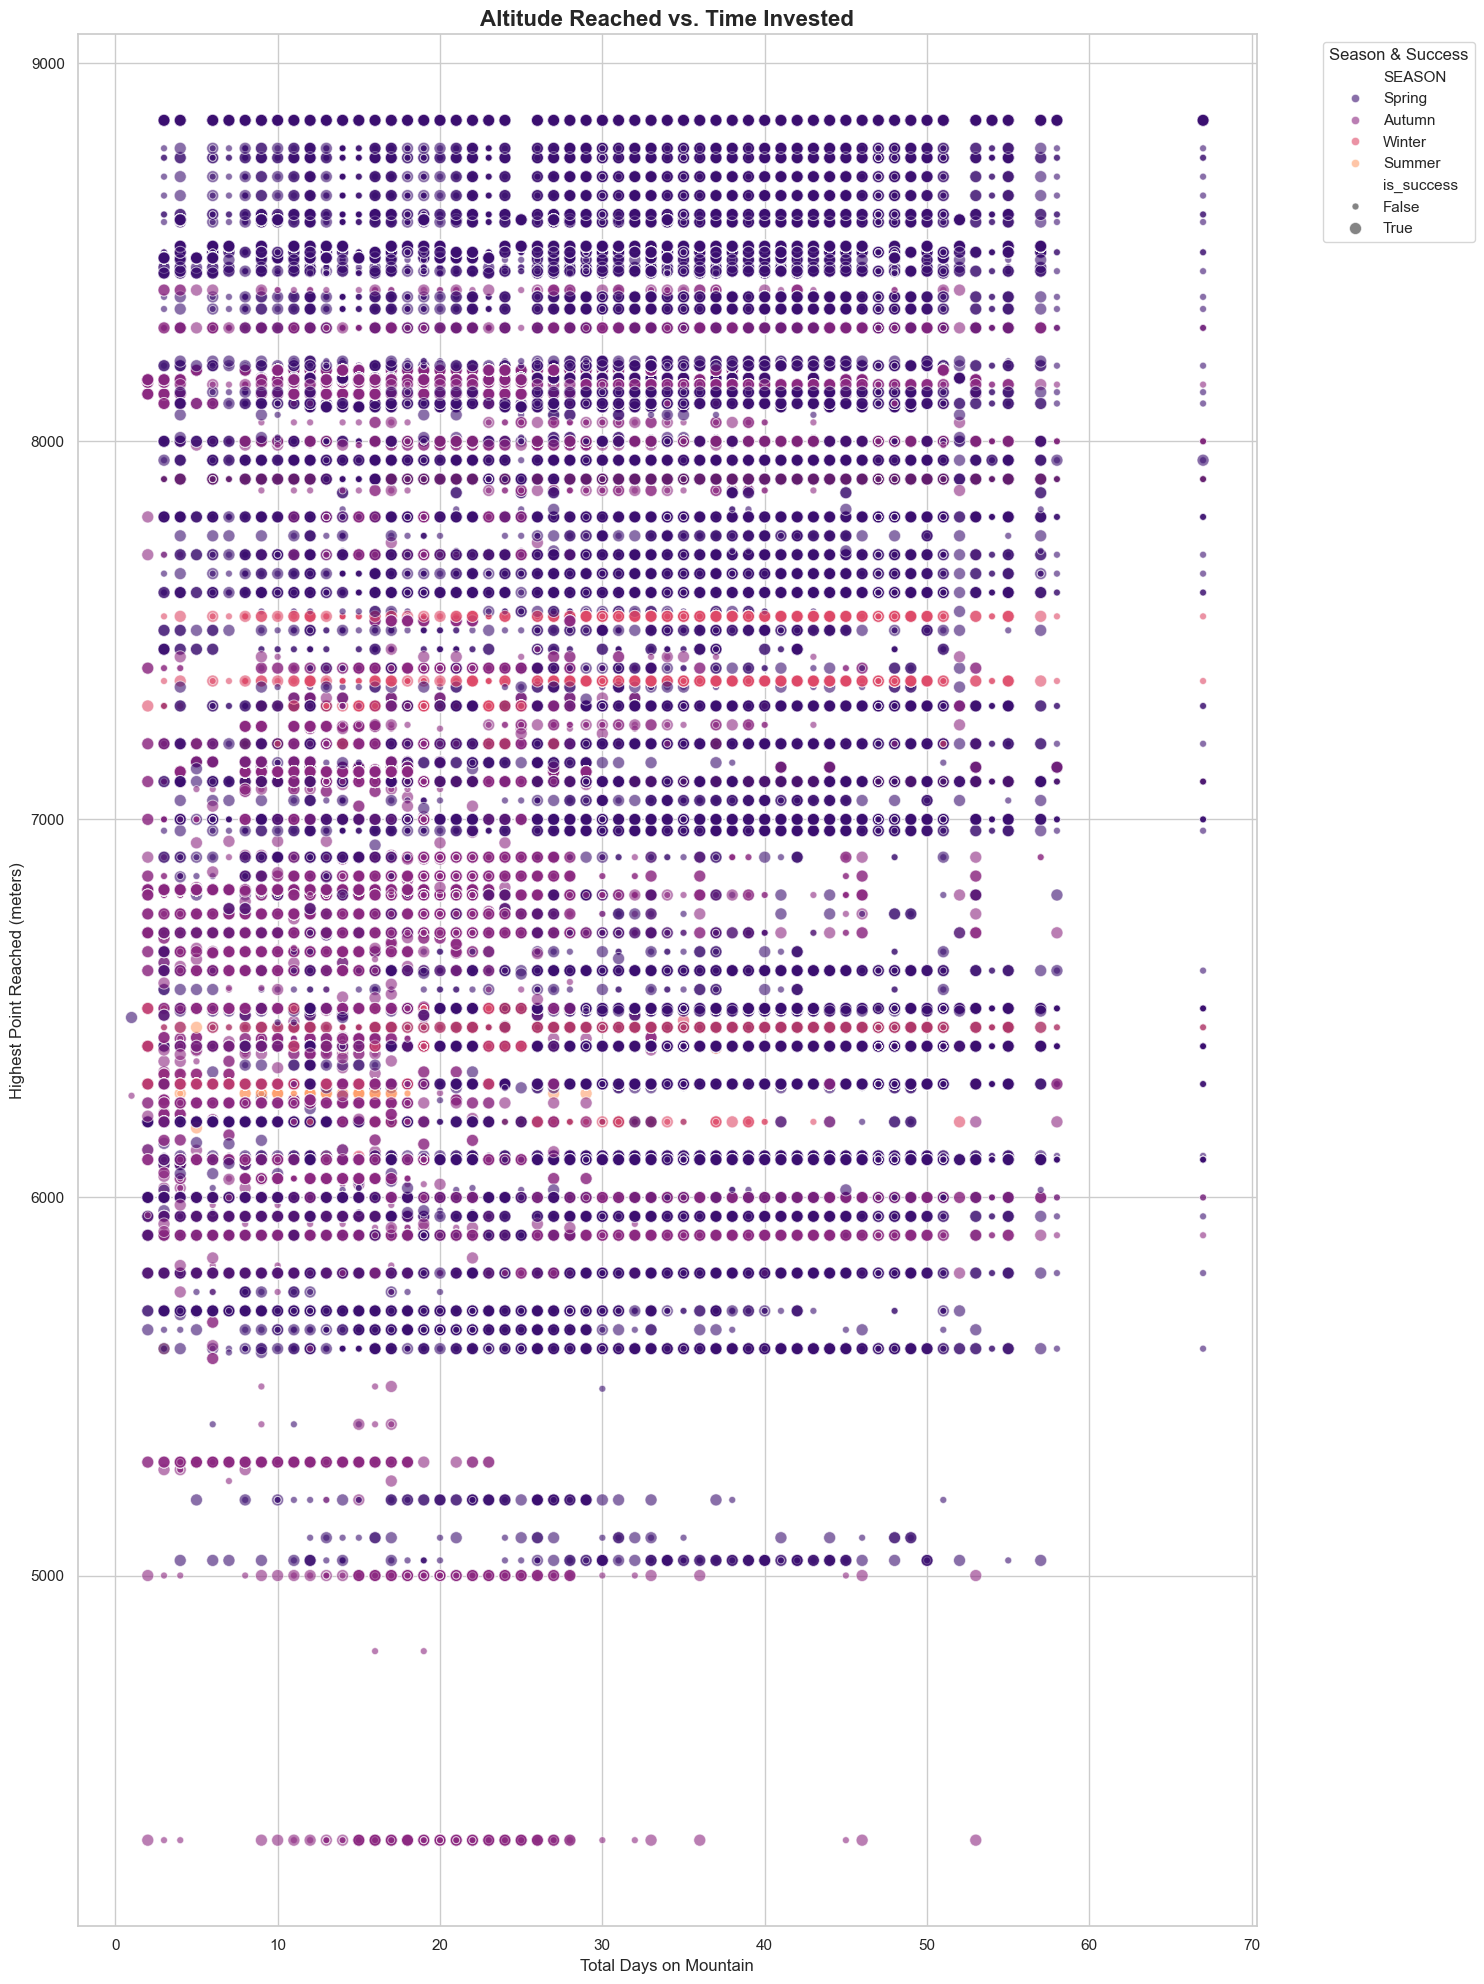

In [18]:

plt.figure(figsize=(15, 20))
sns.set_theme(style="whitegrid")

scatter = sns.scatterplot(
    data=df_clean, 
    x='TOTDAYS', 
    y='HIGHPOINT', 
    hue='SEASON',
    size='is_success', 
    sizes={True: 75, False:25}, 
    alpha=0.6,
    palette='magma'
)

plt.title('Altitude Reached vs. Time Invested', fontsize=16, fontweight='bold')
plt.xlabel('Total Days on Mountain', fontsize=12)
plt.ylabel('Highest Point Reached (meters)', fontsize=12)

plt.legend(title='Season & Success', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()